In [1]:
import numpy as np
import matplotlib.pyplot as plt

## NO COOPERATIVE BINDING

In [ ]:
#defining variables

def compute_occupancy(X, Y):
    Z = ((1+X)**2) * (1+Y)
    AVG = (2*X + 2*X*Y + 2*(X**2) + 2*(X**2)*Y)/Z
    return AVG

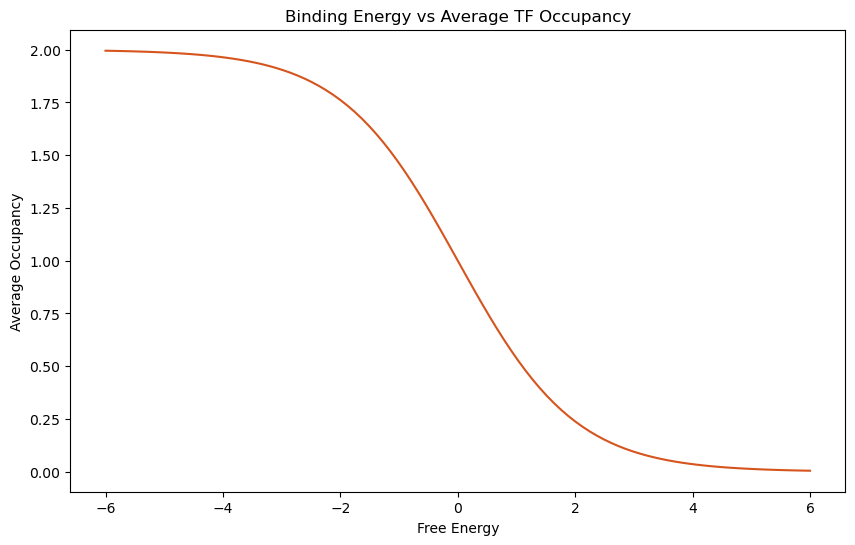

In [32]:
#Thermodynamics / Free Energies

GTF = np.linspace(-6,6,100)
Xt = np.exp(-GTF)
Yt = np.exp(-(-2)) # in excess

AVG_t = compute_occupancy(Xt, Yt)

plt.figure(figsize=(10,6))
plt.plot(GTF, AVG_t, color='#d6541d')
plt.xlabel('Free Energy')
plt.ylabel('Average Occupancy')
plt.title('Binding Energy vs Average TF Occupancy') 

plt.show()

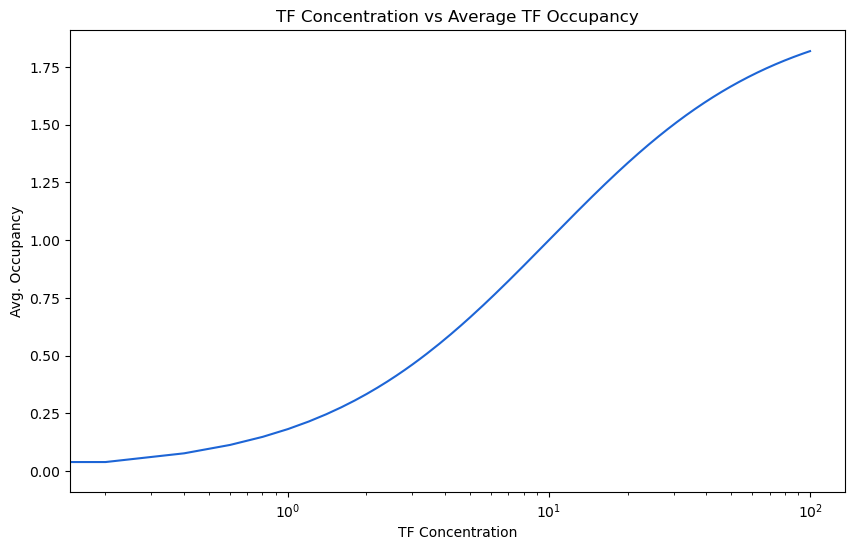

In [34]:
#Kinetics / Concentrations

TFconc = np.linspace(0,100,500)
KdTF = 10
Xk = TFconc / KdTF

RNAPconc = 999 # in excess
kdRNAP = 10
Yk = RNAPconc / kdRNAP 

AVG_k = compute_occupancy(Xk, Yk)

plt.figure(figsize=(10,6))
plt.plot(TFconc, AVG_k, color='#1d65d6')
plt.xlabel('TF Concentration')
plt.ylabel('Avg. Occupancy')
plt.title('TF Concentration vs Average TF Occupancy')

plt.xscale('log')
plt.show()

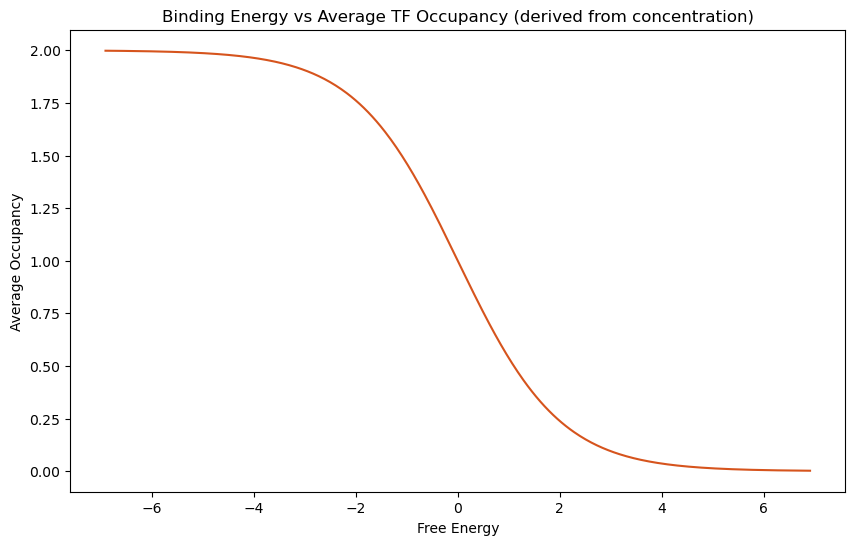

In [30]:
## Thermo: free energies derived from conc. 
from numpy import log

TFconc2 = np.logspace(-3,3, num=500)
GTF2 = -np.log(TFconc2) # G = -log([TF])
Xtc = np.exp(-GTF2) 
Ytc = np.exp(-(-2)) # in excess

AVG_tc = compute_occupancy(Xtc, Ytc)

plt.figure(figsize=(10,6))
plt.plot(GTF2, AVG_tc, color='#d6541d')
plt.xlabel('Free Energy')
plt.ylabel('Average Occupancy')
plt.title('Binding Energy vs Average TF Occupancy (derived from concentration)') 

plt.show()

## WITH COOPERATIVE BINDING

In [47]:
# defining NEW variables
def compute_cooperative_occupancy(X, Y, c):
    Z = (1 + 2*X + c*(X**2)) * (1+Y)
    AVG = (1*(2*X + 2*X*Y) + 2*((c*X**2) + (c*X**2)*Y))/Z
    return AVG

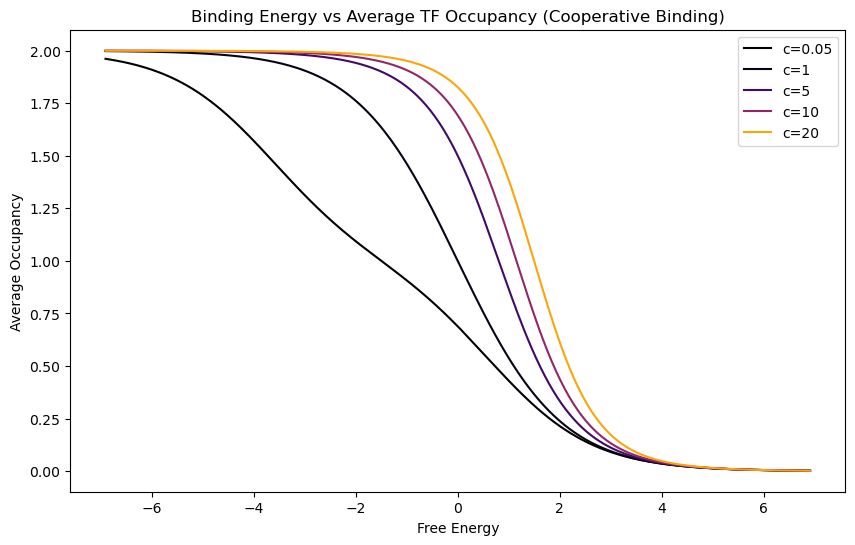

In [54]:
## Thermo: free energies derived from conc. 

TFconc = np.logspace(-3,3, num=500)
GTF = -np.log(TFconc) # G = -log([TF])
X = np.exp(-GTF) 
Y = np.exp(-(-2)) # in excess

plt.figure(figsize=(10,6))

for c_value in [0.05, 1, 5, 10, 20]: # different cooperativity factors
    AVG = compute_cooperative_occupancy(X, Y, c_value)
    plt.plot(GTF, AVG, label=f'c={c_value}', color=plt.cm.inferno(c_value/25))

plt.xlabel('Free Energy')
plt.ylabel('Average Occupancy')
plt.title('Binding Energy vs Average TF Occupancy (Cooperative Binding)') 
plt.legend()

plt.show()